# **EMPLOYEE ATTRITION ANALYSIS**

The dataset contains information about employees, including their demographics, job characteristics, salary-related factors, work environment, career experience, travel, and other workplace-related attributes. These features are used to identify patterns associated with whether an employee leaves the organization.

## What is Employee Attrition?

Employee attrition refers to the process of employees leaving an organization over a period of time. Employees may leave for various reasons, such as better career opportunities, job dissatisfaction, salary, limited career growth, workload, relocation, or other personal and professional factors.

High employee attrition can increase recruitment and training costs and may affect organizational productivity. Analyzing employee data can help identify patterns and factors associated with employees leaving, which can provide useful insights for understanding employee retention.

## Dataset Features

The dataset contains several types of employee-related information:

- **Employee demographics** — `Age`, `Gender`, `MaritalStatus`, `Education`, `EducationField`
- **Job information** — `Department`, `JobRole`, `JobLevel`, `JobInvolvement`, `JobSatisfaction`
- **Salary information** — `MonthlyIncome`, `MonthlyRate`, `HourlyRate`, `DailyRate`, `PercentSalaryHike`
- **Work environment** — `EnvironmentSatisfaction`, `WorkLifeBalance`, `OverTime`
- **Career experience** — `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`, `YearsWithCurrManager`
- **Travel and distance** — `BusinessTravel`, `DistanceFromHome`
- **Other workplace factors** — `NumCompaniesWorked`, `TrainingTimesLastYear`, `StockOptionLevel`, `RelationshipSatisfaction`, `PerformanceRating`

## Target Variable

The target variable is **`Attrition`**, which indicates whether an employee has left the organization.

- `Yes` — Employee left the organization
- `No` — Employee remained with the organization

For machine learning, the target variable is converted into a binary format:

- `1` — Attrition
- `0` — No attrition

In [550]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [551]:
# Loading the dataset

df = pd.read_csv("HR-Employee-Attrition.csv")
pd.set_option("display.max_columns", None)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [552]:
# Checking dataset information, data types, and missing values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [553]:
# Displaying summary statistics of numerical columns

df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [554]:
# Checking for any duplicated rows

df.duplicated().sum()

np.int64(0)

In [555]:
# Checking number of unique values in each column

df.nunique().sort_values(ascending=True)

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [556]:
# Checking columns with one one value

c = ["EmployeeCount","Over18","StandardHours"]
for col in c:
    print(f"\n---{df[col].value_counts()}")


---EmployeeCount
1    1470
Name: count, dtype: int64

---Over18
Y    1470
Name: count, dtype: int64

---StandardHours
80    1470
Name: count, dtype: int64


In [557]:
df.shape

(1470, 35)

### Observations

- The dataset contains **1,470 employee records**.
- The numerical columns contain no missing values, as indicated by the count of 1,470 for each column.
- `EmployeeCount` , `Over18` and `StandardHours` have zero variance and they contain the same value for every employee. These columns do not provide useful information for prediction and can be filtered out.
- `EmployeeNumber` is an employee identifier and does not represent a meaningful predictive feature, so it can also be excluded.
- Several variables are represented numerically but represent ordinal or categorical information, such as `JobSatisfaction`, `JobLevel`, and `PerformanceRating`.

In [558]:
df = df.drop(columns=["EmployeeCount","Over18","StandardHours","EmployeeNumber"])

# Checking if the columns are dropped
df.shape

(1470, 31)

In [559]:
# Checking BusinessTravel column

print(df["BusinessTravel"].unique())

<ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str


In [560]:
# Changing for consistency
df["BusinessTravel"] = df["BusinessTravel"].replace({"Travel_Rarely":"Travel-Rarely","Travel_Frequently":"Travel-Frequently"})
print(df["BusinessTravel"].unique())

<ArrowStringArray>
['Travel-Rarely', 'Travel-Frequently', 'Non-Travel']
Length: 3, dtype: str


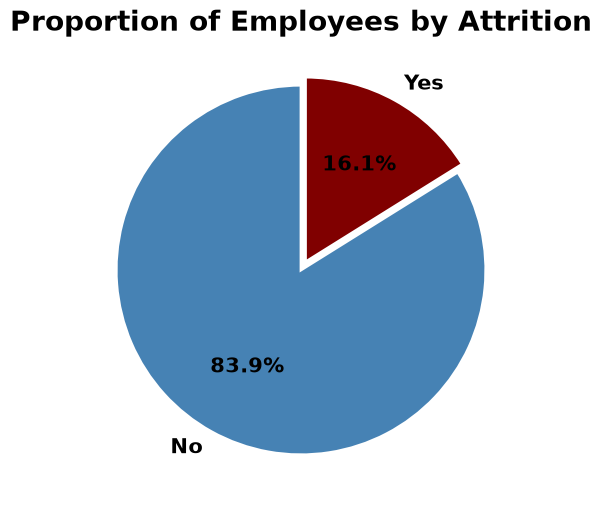

In [561]:
# Plotting the proportion of employees by Attrition

attrition_counts = df["Attrition"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(attrition_counts,labels=attrition_counts.index,autopct="%1.1f%%",colors=["steelblue", "maroon"],startangle=90,explode=[0, 0.05],wedgeprops={"edgecolor": "white", "linewidth":2},textprops={"fontsize":15,"fontweight":"bold"})
plt.title("Proportion of Employees by Attrition", fontweight="bold", fontsize=20)
plt.show()

In [562]:
# Checking for categorical columns with more than 2 categories

cat_cols = df.select_dtypes(include="str").columns
for col in cat_cols :
    if df[col].nunique()>2:
        print(f"\n*{[col]}")
        print(f"-Unique Value Count:{df[col].nunique()}")
        print(f"-Unique Values: {df[col].unique()}")
        print("_"*60)


*['BusinessTravel']
-Unique Value Count:3
-Unique Values: <ArrowStringArray>
['Travel-Rarely', 'Travel-Frequently', 'Non-Travel']
Length: 3, dtype: str
____________________________________________________________

*['Department']
-Unique Value Count:3
-Unique Values: <ArrowStringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str
____________________________________________________________

*['EducationField']
-Unique Value Count:6
-Unique Values: <ArrowStringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str
____________________________________________________________

*['JobRole']
-Unique Value Count:9
-Unique Values: <ArrowStringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Rese

In [563]:
# One Hot Encoding categorical columns with more than two unique categories

for col in cat_cols:
    if df[col].nunique()>2:
        df = pd.get_dummies(df,columns=[col],dtype=int)
        print(f"\nOne Hot Encoded: {col}")
        print("_"*40)


One Hot Encoded: BusinessTravel
________________________________________

One Hot Encoded: Department
________________________________________

One Hot Encoded: EducationField
________________________________________

One Hot Encoded: JobRole
________________________________________

One Hot Encoded: MaritalStatus
________________________________________


In [564]:
# Checking for categorical columns with 2 categories

binary_cols = df.select_dtypes(include="str").columns
for col in binary_cols:
    if df[col].nunique()== 2:
        print(f"\n*{[col]}")
        print(f"-Unique Value Count:{df[col].nunique()}")
        print(f"-Unique Values: {df[col].unique()}")
        print("_"*60)


*['Attrition']
-Unique Value Count:2
-Unique Values: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
____________________________________________________________

*['Gender']
-Unique Value Count:2
-Unique Values: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
____________________________________________________________

*['OverTime']
-Unique Value Count:2
-Unique Values: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
____________________________________________________________


In [565]:
# Label Encoding columns with 2 unique values

le = LabelEncoder()
for col in binary_cols:
    if df[col].nunique()==2:
        df[col] = le.fit_transform(df[col])
        print(f"\n---Label Encoded {col}")
        print(dict(zip(le.classes_,le.transform(le.classes_))))
        print("_"*50)


---Label Encoded Attrition
{'No': np.int64(0), 'Yes': np.int64(1)}
__________________________________________________

---Label Encoded Gender
{'Female': np.int64(0), 'Male': np.int64(1)}
__________________________________________________

---Label Encoded OverTime
{'No': np.int64(0), 'Yes': np.int64(1)}
__________________________________________________


In [566]:
# All data types are int

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   Gender                             1470 non-null   int64
 7   HourlyRate                         1470 non-null   int64
 8   JobInvolvement                     1470 non-null   int64
 9   JobLevel                           1470 non-null   int64
 10  JobSatisfaction                    1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  MonthlyRate                    

In [567]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel-Frequently,BusinessTravel_Travel-Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0


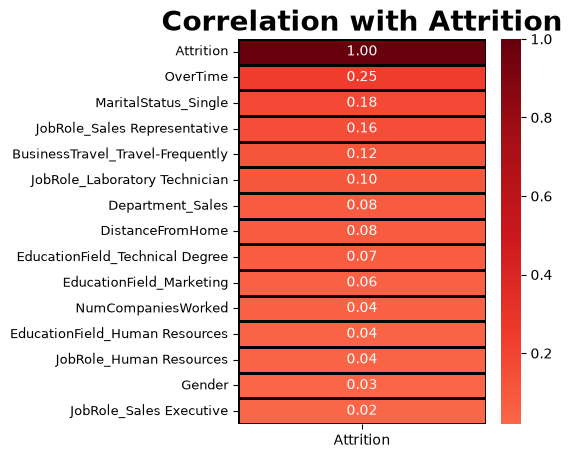

In [589]:
# Plotting a Correlation Heatmap. Checking Top 15 most correlated features with Attrition

corr= df.corr(numeric_only = True)[["Attrition"]].sort_values(by="Attrition",ascending=False).head(15)
plt.figure(figsize=(4,5))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="Reds",center=0 ,linewidth=1,linecolor="black")
plt.yticks(fontsize=9)
plt.title("Correlation with Attrition", fontsize=20, fontweight="bold")
plt.show()

In [590]:
# Separating Features and Target

X = df.drop(columns=["Attrition"])
y = df["Attrition"]

In [591]:
print(X.shape)
print(y.shape)

(1470, 49)
(1470,)


In [592]:
# Splitting the data into Training set (80%) and Test set (20%)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = 42)

In [593]:
# Standardize the numerical features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [594]:
lr = LogisticRegression(class_weight = "balanced", random_state = 42)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:,1]

print("---Accuracy:", round(accuracy_score(y_test, y_pred),2))
print("\n---Classification Report:")
print(classification_report(y_test, y_pred))
print("\n---Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_prob),2))

---Accuracy: 0.74

---Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.33      0.60      0.43        47

    accuracy                           0.74       294
   macro avg       0.62      0.68      0.63       294
weighted avg       0.82      0.74      0.77       294


---Confusion Matrix:
[[191  56]
 [ 19  28]]

ROC-AUC Score: 0.8


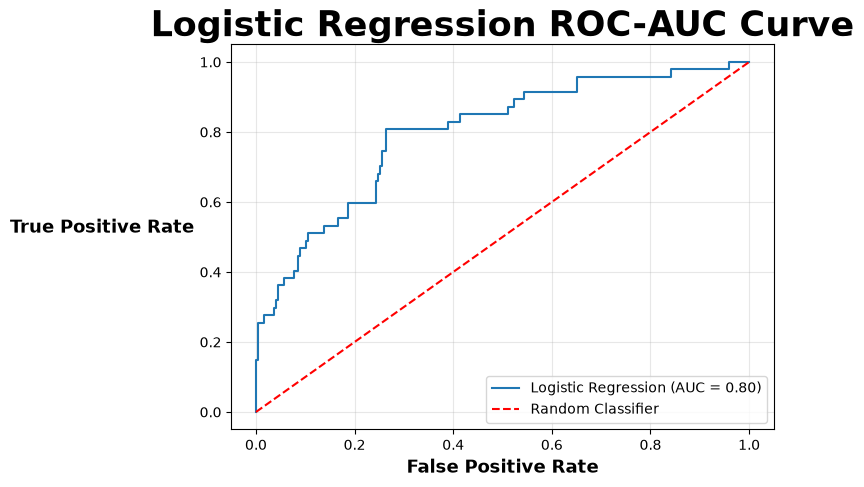

In [596]:
# ROC-AUC Curve: Logistic Regression

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], "r--", label="Random Classifier")
plt.xlabel("False Positive Rate", fontweight="bold",fontsize=13)
plt.ylabel("True Positive Rate",rotation=0, ha="right", fontweight="bold",fontsize=13)
plt.title("Logistic Regression ROC-AUC Curve",fontsize = 25, fontweight = "bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Random Forest Classifier

In [597]:
forest = RandomForestClassifier(class_weight = "balanced", max_depth=6, min_samples_leaf=3, min_samples_split=2, n_estimators=300)
forest.fit(X_train, y_train)
y_pred_rf = forest.predict(X_test)
y_prob_rf = forest.predict_proba(X_test)[:,1]

print("---Accuracy:", round(accuracy_score(y_test, y_pred_rf),2))
print("\n---Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("\n---Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_prob_rf), 2))

---Accuracy: 0.81

---Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88       247
           1       0.44      0.60      0.50        47

    accuracy                           0.81       294
   macro avg       0.68      0.72      0.69       294
weighted avg       0.84      0.81      0.82       294


---Confusion Matrix:
[[211  36]
 [ 19  28]]

ROC-AUC Score: 0.78


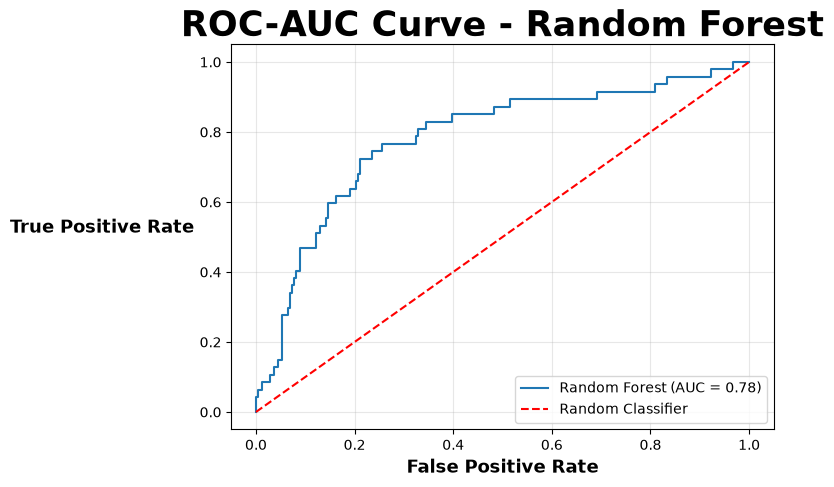

In [598]:
# ROC-AUC Curve: Random Forest

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf,tpr_rf,label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot([0, 1],[0, 1],"r--",label="Random Classifier")
plt.xlabel("False Positive Rate",fontweight="bold",fontsize=13)
plt.ylabel("True Positive Rate",rotation=0, ha="right", fontweight="bold",fontsize=13)
plt.title("ROC-AUC Curve - Random Forest",fontsize = 25, fontweight = "bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

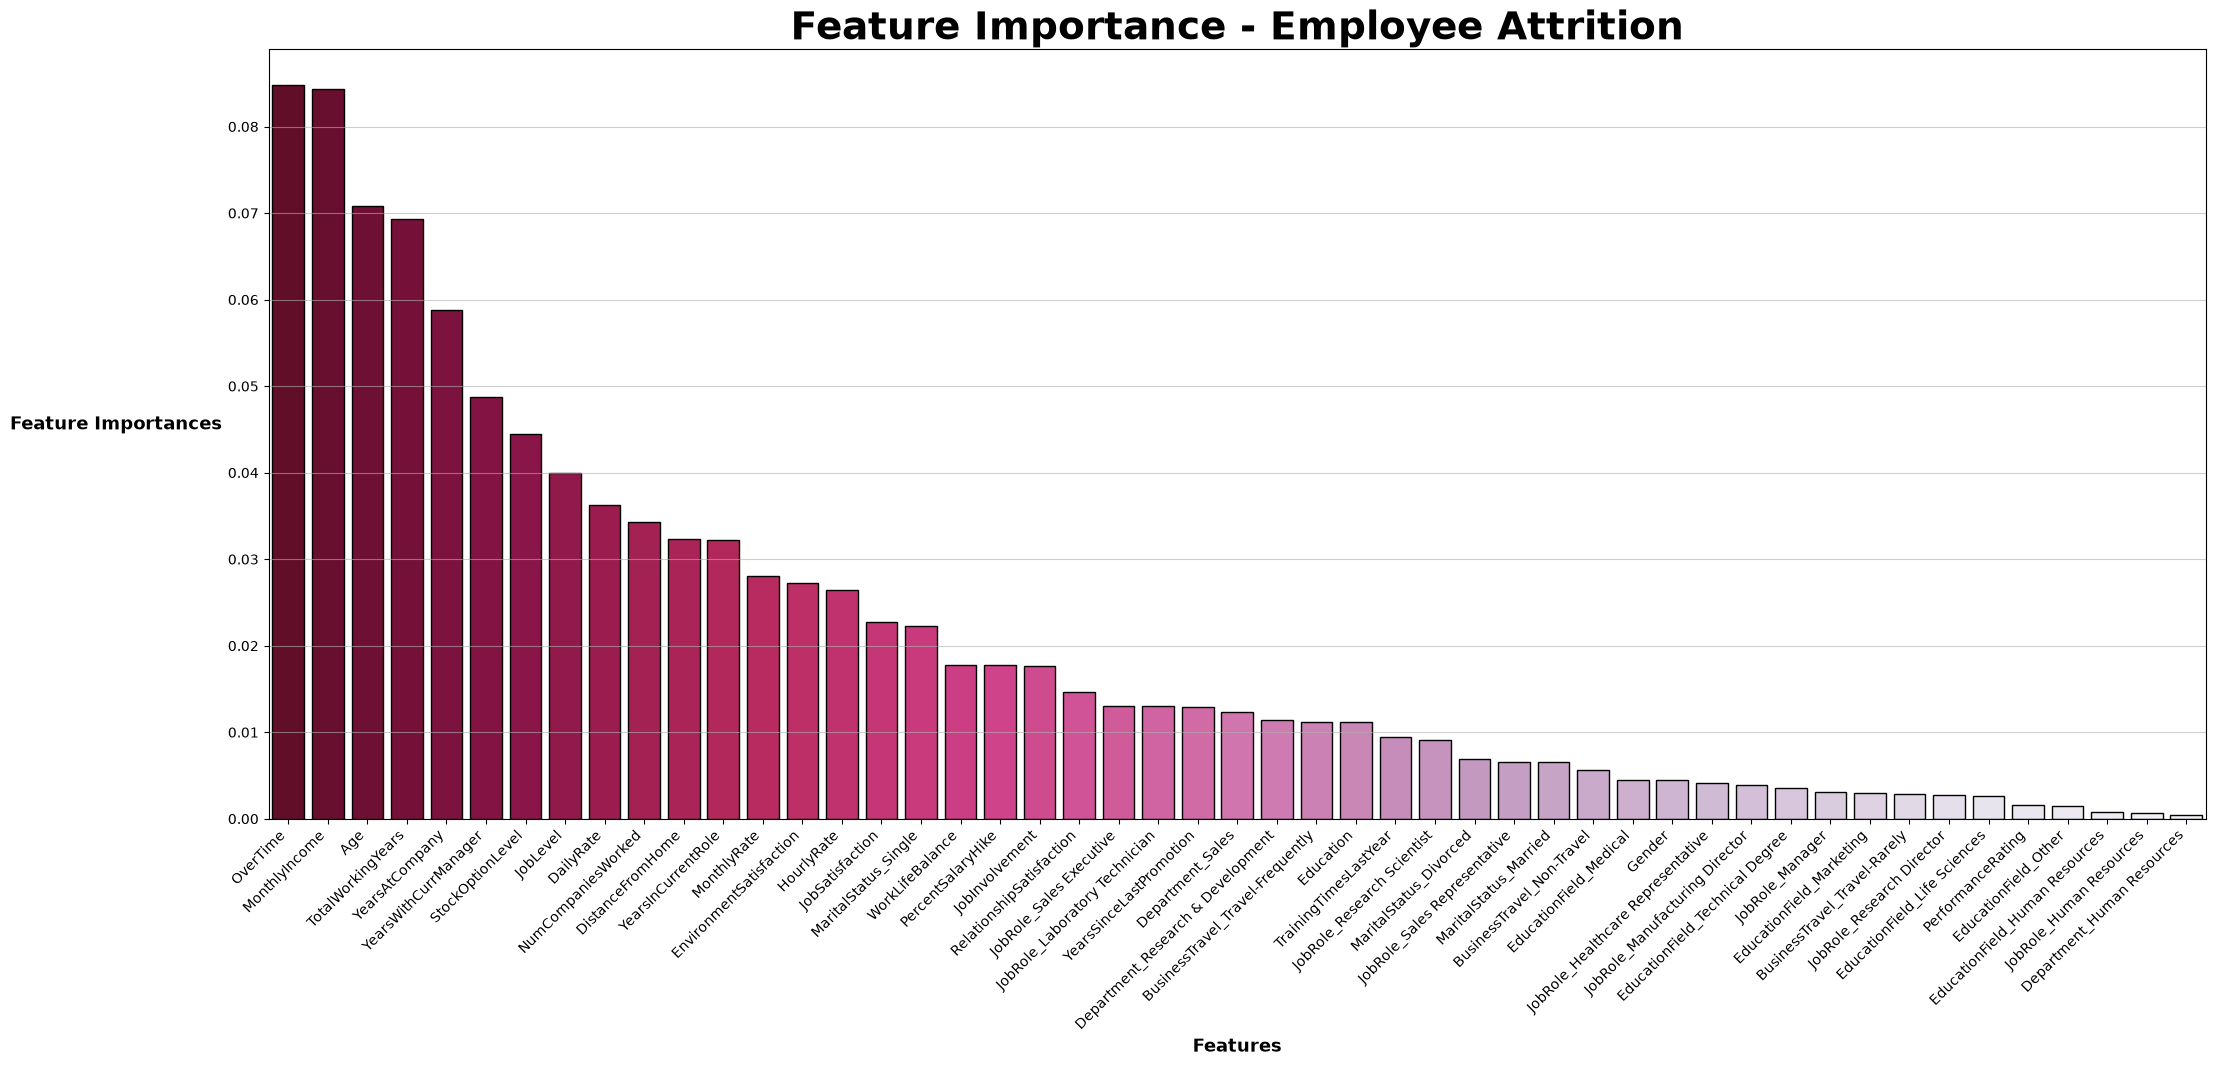

In [631]:
importances = forest.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(25,10))
bars = sns.barplot(x=X.columns[indices],y=importances[indices],hue=X.columns[indices], palette="PuRd_r", ec="k")
plt.title("Feature Importance - Employee Attrition",fontsize = 28, fontweight = "bold")
plt.xlabel("Features", fontweight="bold",fontsize=13)
plt.ylabel("Feature Importances", rotation=0, ha="right", fontweight="bold",fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="-",alpha=0.6)
plt.show()

In [616]:
# Explainability with SHAP

explainer = shap.Explainer(forest)
shap_values = explainer(X_test)

In [617]:
# 294 rows, 49 fetaures and 2 classes

print(shap_values.shape)

(294, 49, 2)


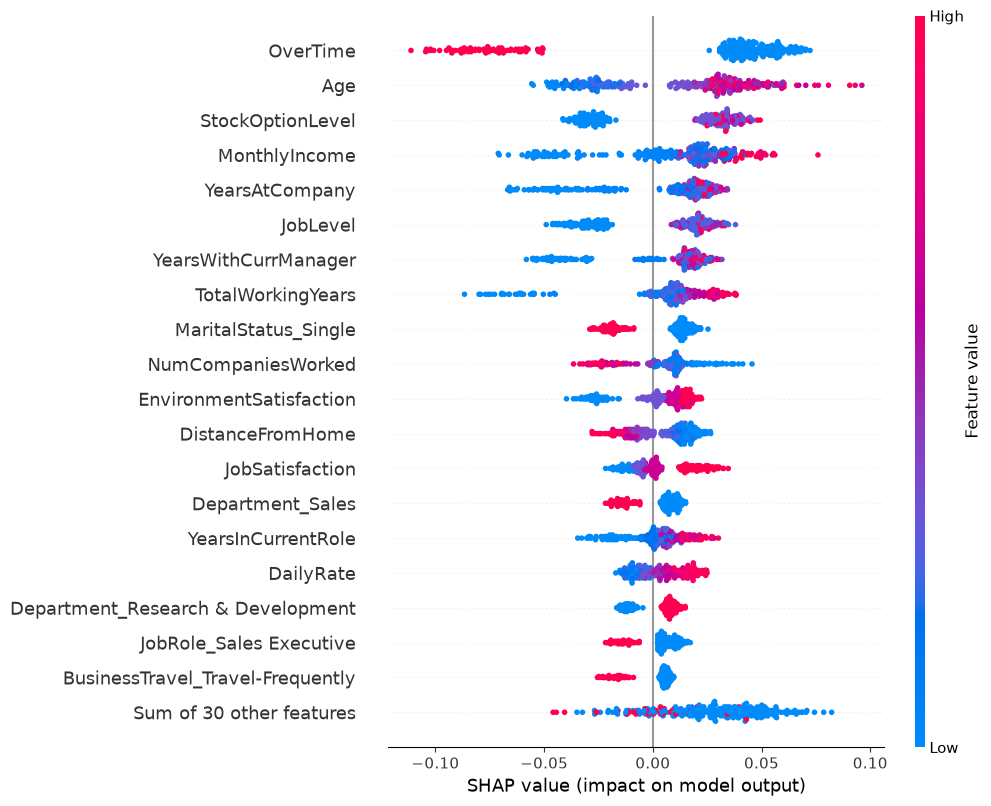

In [618]:
# Attrition (No/0)

plt.figure(figsize=(8, 6))
shap.plots.beeswarm(shap_values[:, :, 0], max_display=20)
plt.show()

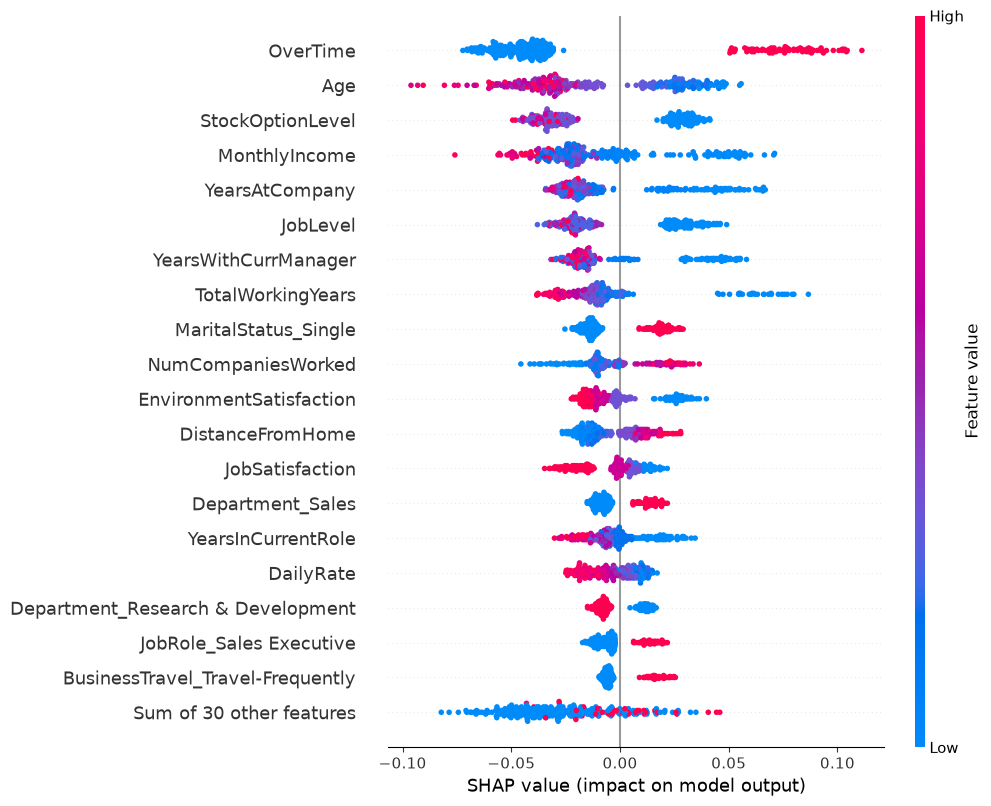

In [619]:
# Attrition (Yes/1)

plt.figure(figsize=(8, 6))
shap.plots.beeswarm(shap_values[:, :, 1], max_display=20)
plt.show()

In [620]:
# Saving the trained Random Forest
joblib.dump(forest, "random_forest_model.pkl")

# Saving the feature names and their order
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']